In [1]:
import pandas as pd
import os
os.chdir("D:\loan prediction")

# Load dataset
df = pd.read_csv("loan_data.csv")   # change to your filename


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
C:\Users\tejas\AppData\Local\Temp\ipykernel_33640\1737762256.py:3: SyntaxWarning: invalid escape sequence '\l'
  os.chdir("D:\loan prediction")


In [2]:
display(df.head())


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
display(df.describe())


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
display(df.describe(include='object'))


,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
count,45000,45000,45000,45000,45000
unique,2,5,4,6,2
top,male,Bachelor,RENT,EDUCATION,Yes
freq,24841,13399,23443,9153,22858


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv("loan_data.csv")

# Columns we will inspect
cols = ['person_income', 'loan_amnt']

# Make full copies of original columns so we can compare
for c in cols:
    df[f"{c}_orig"] = df[c].copy()


#Outlier detection function + report (before)

In [7]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

def outlier_count(series):
    lower, upper = iqr_bounds(series)
    return ((series < lower) | (series > upper)).sum()

# Print outlier counts before capping
print("Outlier counts BEFORE capping:")
for c in cols:
    cnt = outlier_count(df[c])
    total = df.shape[0]
    print(f" {c}: {cnt} outliers  ({cnt/total*100:.2f}%)")


Outlier counts BEFORE capping:
 person_income: 2218 outliers  (4.93%)
 loan_amnt: 2348 outliers  (5.22%)


#Plot BEFORE (boxplot + histogram)

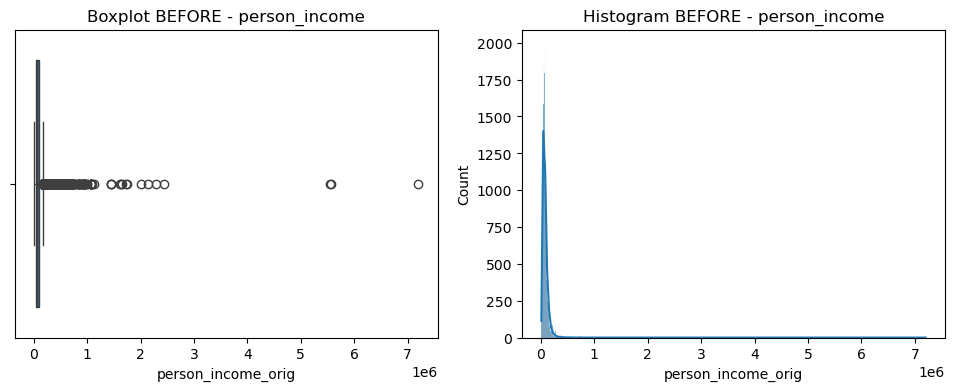

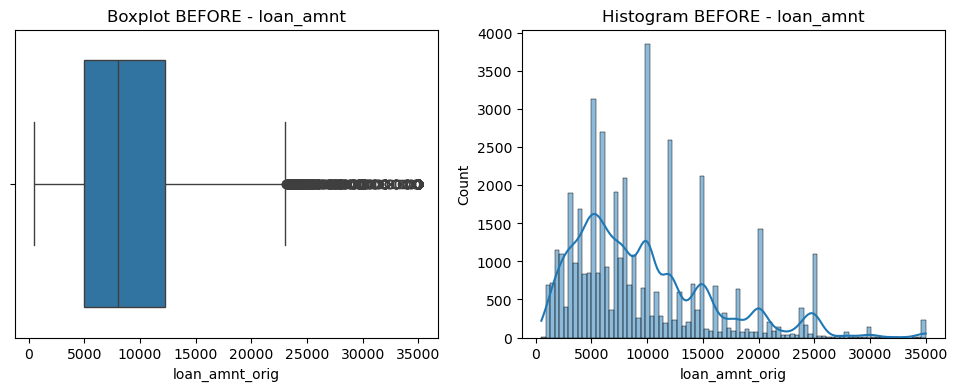

In [8]:
for c in cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=df[f"{c}_orig"])
    plt.title(f"Boxplot BEFORE - {c}")

    plt.subplot(1,2,2)
    sns.histplot(df[f"{c}_orig"], kde=True)
    plt.title(f"Histogram BEFORE - {c}")

    plt.show()


#Define and apply capping function

In [9]:
def cap_outliers_inplace(df, col):
    lower, upper = iqr_bounds(df[col])
    df[col] = df[col].clip(lower, upper)
    return lower, upper

# Apply capping and record bounds used
bounds = {}
for c in cols:
    bounds[c] = cap_outliers_inplace(df, c)
    print(f"Capped {c} to bounds {bounds[c]}")


Capped person_income to bounds (-25673.875, 168667.125)
Capped loan_amnt to bounds (-5855.875, 23093.125)


#Outlier counts AFTER capping

In [10]:
print("Outlier counts AFTER capping:")
for c in cols:
    cnt = outlier_count(df[c])
    total = df.shape[0]
    print(f" {c}: {cnt} outliers  ({cnt/total*100:.2f}%)")


Outlier counts AFTER capping:
 person_income: 0 outliers  (0.00%)
 loan_amnt: 0 outliers  (0.00%)


#Plot AFTER (boxplot + histogram)

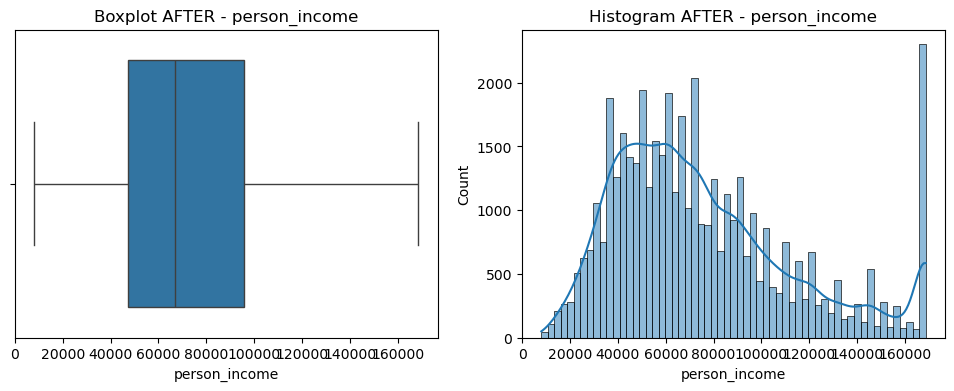

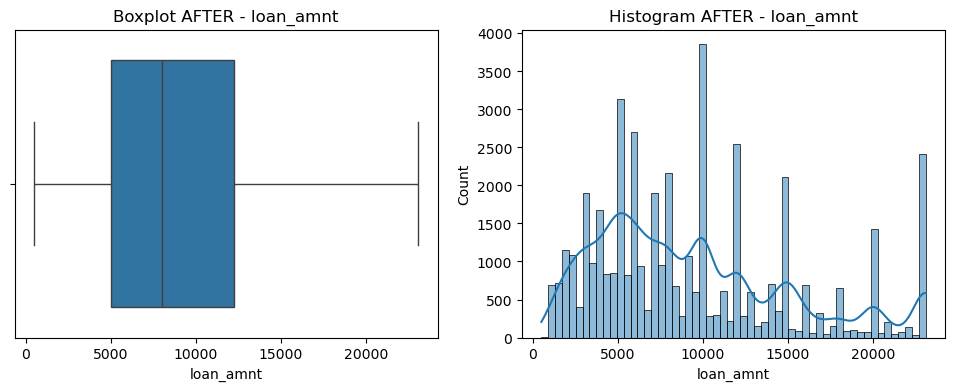

In [11]:
for c in cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=df[c])
    plt.title(f"Boxplot AFTER - {c}")

    plt.subplot(1,2,2)
    sns.histplot(df[c], kde=True)
    plt.title(f"Histogram AFTER - {c}")

    plt.show()


#Bar chart: number of outliers before vs after

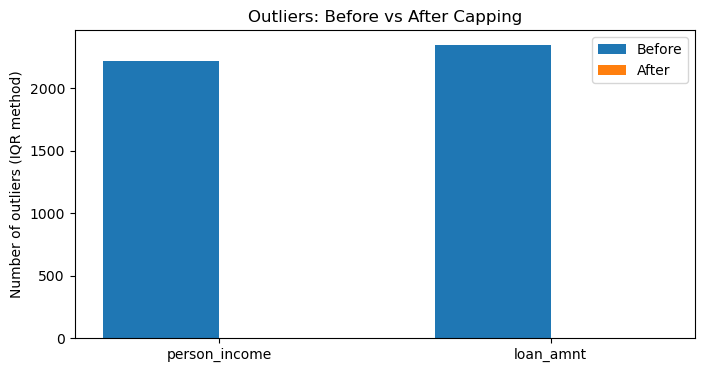

In [12]:
before_counts = []
after_counts = []
for c in cols:
    before_counts.append(outlier_count(df[f"{c}_orig"]))
    after_counts.append(outlier_count(df[c]))

x = np.arange(len(cols))
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, before_counts, width, label='Before')
ax.bar(x + width/2, after_counts, width, label='After')
ax.set_xticks(x)
ax.set_xticklabels(cols)
ax.set_ylabel("Number of outliers (IQR method)")
ax.set_title("Outliers: Before vs After Capping")
ax.legend()
plt.show()


In [13]:
# ============================
# BINARY ENCODING (Yes/No → 0/1)
# ============================
df["previous_loan_defaults_on_file"] = df["previous_loan_defaults_on_file"].map({
    "No": 0,
    "Yes": 1,
    False: 0,
    True: 1
}).astype(int)

# ============================
# ONE-HOT ENCODING (0/1 columns)
# ============================
cat_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ============================
# ENSURE ALL BOOLEAN COLUMNS BECOME 0/1
# ============================
for col in df.columns:
    if df[col].dtype == "bool":
        df[col] = df[col].astype(int)


In [14]:
df.head()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,...,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,23093.125,16.02,0.49,3.0,561,0,1,...,0,1,0,0,1,0,0,0,1,0
1,21.0,12282.0,0,1000.000,11.14,0.08,2.0,504,1,0,...,1,0,0,1,0,1,0,0,0,0
2,25.0,12438.0,3,5500.000,12.87,0.44,3.0,635,0,1,...,1,0,0,0,0,0,0,1,0,0
3,23.0,79753.0,0,23093.125,15.23,0.44,2.0,675,0,1,...,0,0,0,0,1,0,0,1,0,0
4,24.0,66135.0,1,23093.125,14.27,0.53,4.0,586,0,1,...,0,1,0,0,1,0,0,1,0,0


In [15]:
# After ALL preprocessing steps
df.to_csv("processed_loan_data.csv", index=False)

print("Saved processed_loan_data.csv successfully!")


Saved processed_loan_data.csv successfully!


In [16]:
# ============================
# FEATURE ENGINEERING
# ============================

# 1. Approximate EMI (based on interest burden)
df["approx_emi"] = df["loan_amnt"] * (df["loan_int_rate"] / 100)

# 2. Balance income after paying interest
df["balance_income"] = df["person_income"] - df["approx_emi"]

# 3. Debt-to-Income Ratio (DTI)
df["dti"] = df["loan_amnt"] / (df["person_income"] + 1)

# 4. Credit age relative to person's age
df["credit_age_ratio"] = df["cb_person_cred_hist_length"] / (df["person_age"] + 1)

# 5. Income per year of experience
df["income_exp_ratio"] = df["person_income"] / (df["person_emp_exp"] + 1)

# 6. Log transforms (optional but powerful)
df["log_person_income"] = np.log1p(df["person_income"])
df["log_loan_amnt"] = np.log1p(df["loan_amnt"])


In [17]:
df.to_csv("processed_loan_data.csv", index=False)

#Train–Test Split

In [18]:
from sklearn.model_selection import train_test_split

# Load the processed dataset
df = pd.read_csv("processed_loan_data.csv")

# -----------------------------
# 1. Separate features and target
# -----------------------------
X = df.drop("loan_status", axis=1)   # all features
y = df["loan_status"]                # target (0/1)

# -----------------------------
# 2. Train-Test Split (STRATIFIED)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y     # keeps class balance same in train & test
)

# -----------------------------
# 3. Confirm split shapes
# -----------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

X_train shape: (36000, 31)
X_test shape: (9000, 31)
y_train shape: (36000,)
y_test shape: (9000,)

Class distribution in training set:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

Class distribution in test set:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64
